In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../morphology/morphology_outputs/slide_2_test.csv")

features = [
    "length_pixels",
    "num_branches",
    "num_components",
    "soma_area",
    "soma_perimeter",
    "soma_circularity",
    "cell_area",
    "cell_perimeter",
    "cell_convex_hull_area",
    "cell_convex_hull_perimeter",
    "cell_solidity",
    "cell_convexity",
    "cell_circularity",
]


Histogram of all features

C:\Users\chris\AppData\Local\Temp\ipykernel_31316\4144483297.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


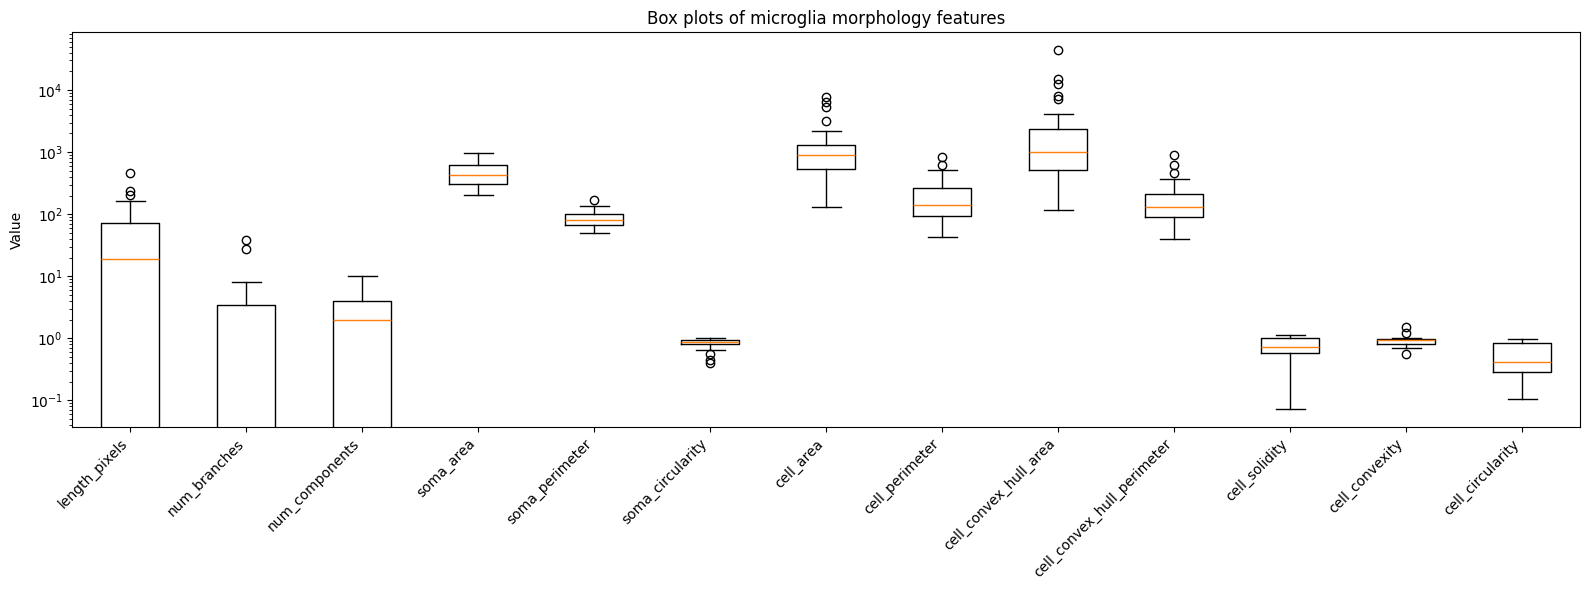

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
plt.boxplot(
    [df[f].dropna() for f in features],
    labels=features,
    vert=True
)
plt.yscale("log")


plt.xticks(rotation=45, ha="right")
plt.ylabel("Value")
plt.title("Box plots of microglia morphology features")
plt.tight_layout()
plt.show()


Histogram of a selected feature

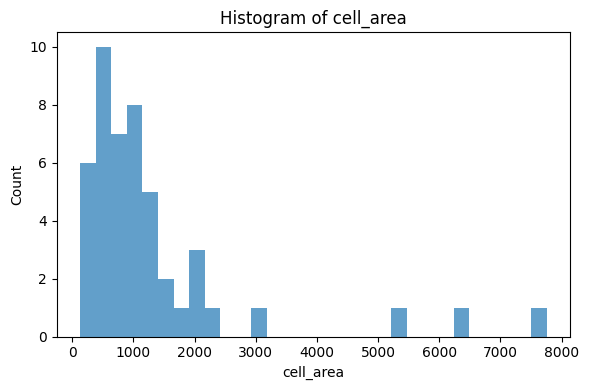

In [4]:
import matplotlib.pyplot as plt

feature = "cell_area"

plt.figure(figsize=(6, 4))
plt.hist(df[feature].dropna(), bins=30, alpha=0.7)
plt.xlabel(feature)
plt.ylabel("Count")
plt.title(f"Histogram of {feature}")
plt.tight_layout()
plt.show()


Scatter plot of 2 features

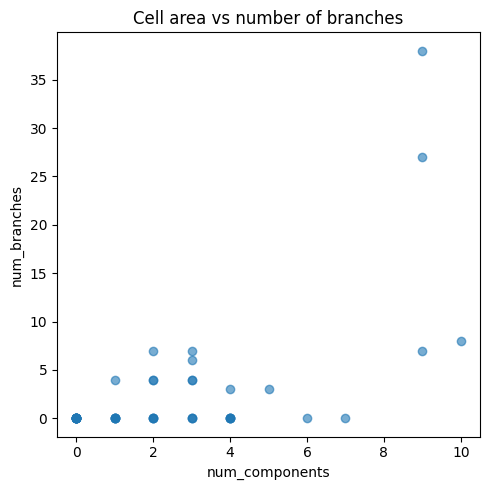

In [5]:
feature_x = "num_components"
feature_y = 'num_branches'

plt.figure(figsize=(5, 5))
plt.scatter(
    df[feature_x],
    df[feature_y],
    alpha=0.6
)
plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title("Cell area vs number of branches")
plt.tight_layout()
plt.show()


Correlation Matrix

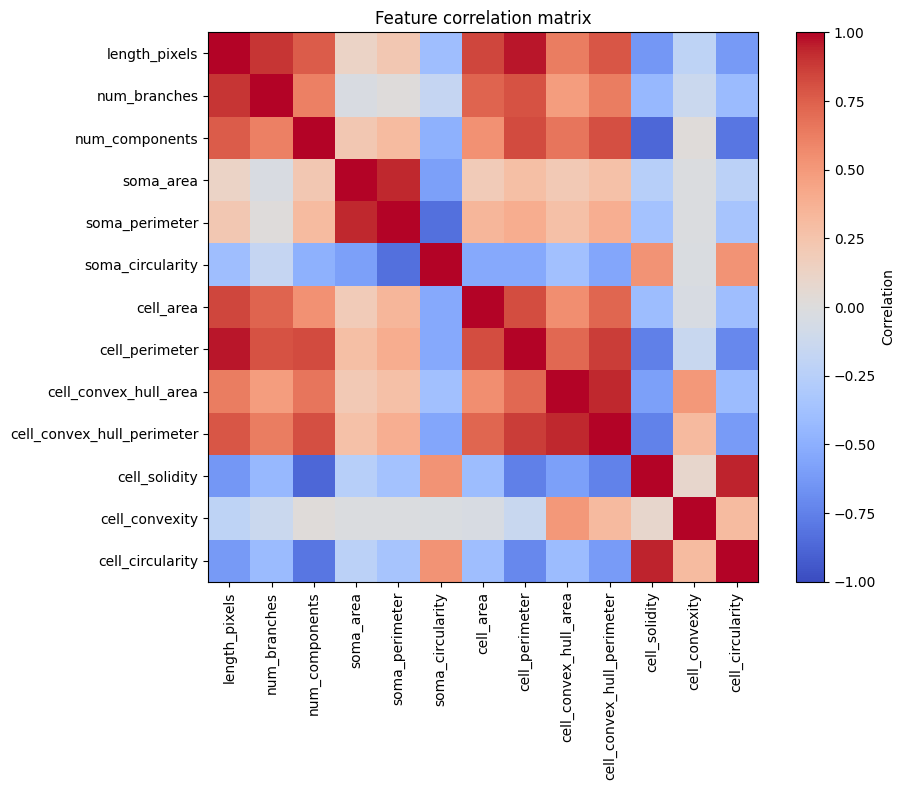

In [6]:
corr = df[features].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()


PCA Plot

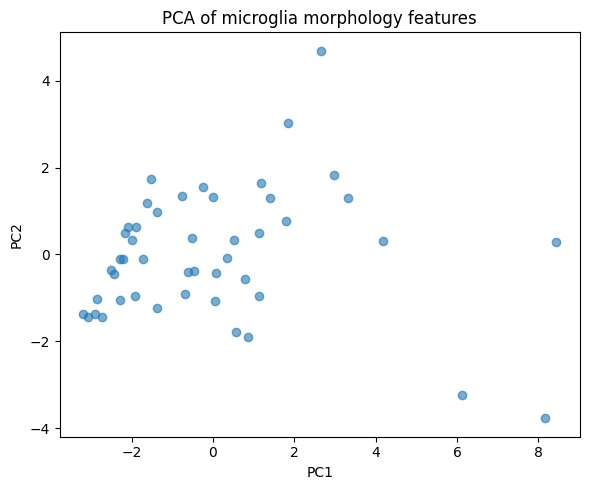

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[features].dropna()
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of microglia morphology features")
plt.tight_layout()
plt.show()


Basic Clustering

In [12]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans

# Hierarchical clustering into 4 clusters
# clusterer = AgglomerativeClustering(
#     n_clusters=4,
#     linkage="ward"
# )

clusterer = KMeans(
    n_clusters=4,
    n_init=50,
    random_state=0
)


cluster_labels = clusterer.fit_predict(X_scaled)
df_clustered = df.loc[X.index].copy()
df_clustered["cluster"] = cluster_labels



In [13]:
from scipy.spatial.distance import cdist

representatives = []

for cluster_id in sorted(df_clustered["cluster"].unique()):
    cluster_mask = df_clustered["cluster"] == cluster_id
    
    # Feature vectors for this cluster
    X_cluster = X_scaled[cluster_mask.values]
    
    # Centroid
    centroid = X_cluster.mean(axis=0, keepdims=True)
    
    # Distance to centroid
    distances = cdist(X_cluster, centroid, metric="euclidean").flatten()
    
    # Index of closest point
    closest_idx = np.argmin(distances)
    
    # Global dataframe index
    global_index = df_clustered[cluster_mask].iloc[closest_idx].name
    
    representatives.append({
        "cluster": cluster_id,
        "global_cell_id": df.loc[global_index, "global_cell_id"],
        "distance_to_centroid": distances[closest_idx]
    })


for r in representatives:
    print(
        f"Cluster {r['cluster']}: "
        f"representative global_cell_id = {r['global_cell_id']} "
        f"(distance = {r['distance_to_centroid']:.3f})"
    )



Cluster 0: representative global_cell_id = tile_01426_x40960_y14336_cell_2 (distance = 0.248)
Cluster 1: representative global_cell_id = tile_01425_x39936_y14336_cell_11 (distance = 1.565)
Cluster 2: representative global_cell_id = tile_01425_x39936_y14336_cell_6 (distance = 0.805)
Cluster 3: representative global_cell_id = tile_01426_x40960_y14336_cell_16 (distance = 2.708)


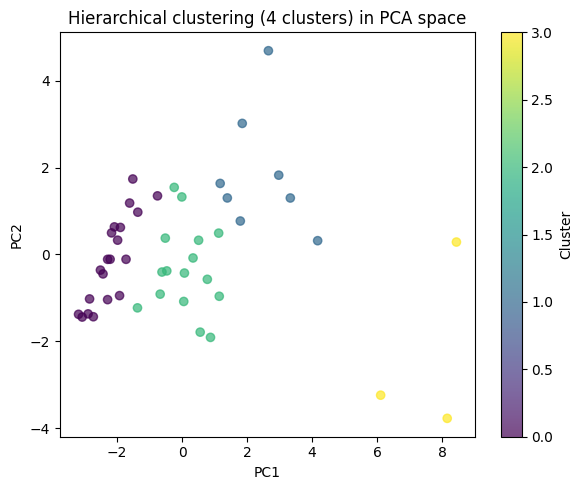

In [14]:
plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical clustering (4 clusters) in PCA space")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()
